In [2]:

from PIL import Image
import matplotlib.pyplot as plt
import os

# Folder paths
uninfected_path = "/kaggle/input/cell-images-for-detecting-malaria/cell_images/Uninfected"
parasitized_path = "/kaggle/input/cell-images-for-detecting-malaria/cell_images/Parasitized"

#uninfected_path = "/Users/rushi/Documents/ADS2002/Project/Uninfected"
#parasitized_path = "/Users/rushi/Documents/ADS2002/Project/Parasitized"

# Exploratory Data Analysis (EDA)

In [3]:
# ### Determine the Number of Images in Both Uninfected and Parasitized


import numpy as np

uninfected_count = len([f for f in os.listdir(uninfected_path) if f.endswith(('.png', '.jpg', '.jpeg'))])
parasitized_count = len([f for f in os.listdir(parasitized_path) if f.endswith(('.png', '.jpg', '.jpeg'))])

print("Total number of images in Uninfected: " + str(uninfected_count))
print("Total number of images in Parasitized: " + str(parasitized_count))


Total number of images in Uninfected: 13779
Total number of images in Parasitized: 13779


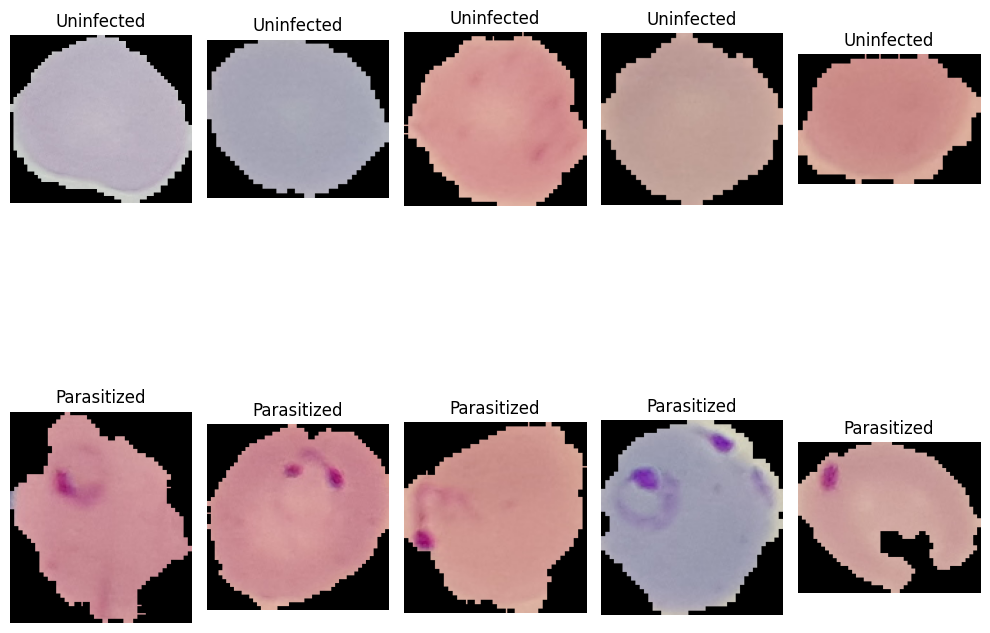

In [22]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Number of images to display
num_images = 5

# Get image file names
uninfected_files = [f for f in os.listdir(uninfected_path) if f.endswith(('.png', '.jpg'))][:num_images]
parasitized_files = [f for f in os.listdir(parasitized_path) if f.endswith(('.png', '.jpg'))][:num_images]

# Plot sample images
plt.figure(figsize=(10, 10))

# Uninfected
for i, file in enumerate(uninfected_files):
    img = Image.open(os.path.join(uninfected_path, file))
    plt.subplot(2, num_images, i + 1)
    plt.imshow(img)
    plt.title("Uninfected")
    plt.axis('off')

# Parasitized
for i, file in enumerate(parasitized_files):
    img = Image.open(os.path.join(parasitized_path, file))
    plt.subplot(2, num_images, num_images + i + 1)
    plt.imshow(img)
    plt.title("Parasitized")
    plt.axis('off')

plt.tight_layout()
plt.show()

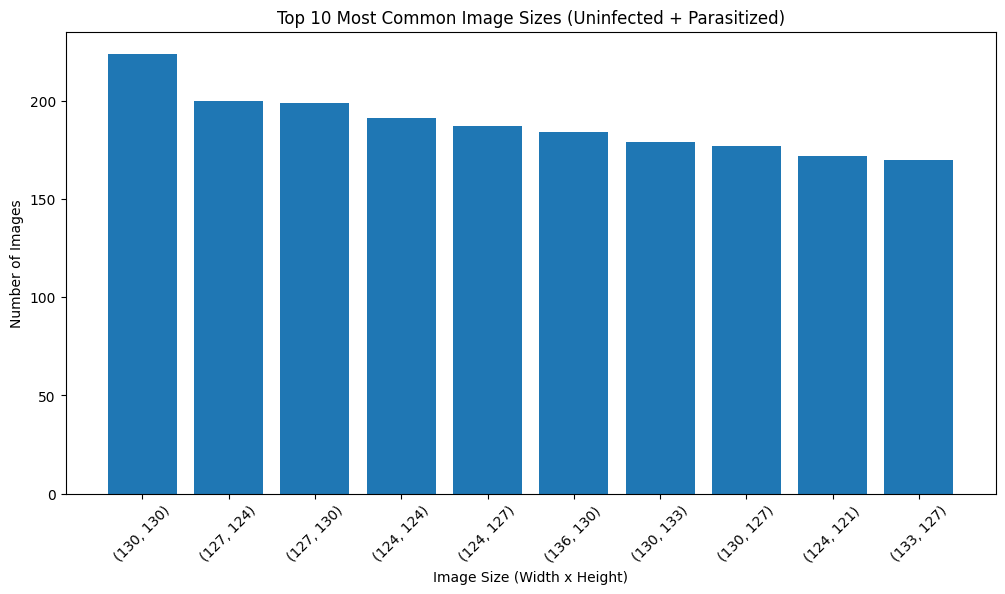

,Size,Count,Width,Height
83,"(130, 130)",224,130,130
9,"(127, 124)",200,127,124
68,"(127, 130)",199,127,130
67,"(124, 124)",191,124,124
135,"(124, 127)",187,124,127
12,"(136, 130)",184,136,130
216,"(130, 133)",179,130,133
35,"(130, 127)",177,130,127
132,"(124, 121)",172,124,121
143,"(133, 127)",170,133,127


In [23]:
import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter

# Kaggle dataset paths
uninfected_path = "/kaggle/input/cell-images-for-detecting-malaria/cell_images/Uninfected"
parasitized_path = "/kaggle/input/cell-images-for-detecting-malaria/cell_images/Parasitized"

# Combine both folders
all_files = []
for folder in [uninfected_path, parasitized_path]:
    files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(('.png', '.jpg'))]
    all_files.extend(files)

# Extract image sizes (width, height)
sizes = []
for file in all_files:
    with Image.open(file) as img:
        sizes.append(img.size)

# Count frequency of each image size
size_counts = Counter(sizes)

# Convert to DataFrame
df_sizes = pd.DataFrame(size_counts.items(), columns=['Size', 'Count'])
df_sizes['Width'] = df_sizes['Size'].apply(lambda x: x[0])
df_sizes['Height'] = df_sizes['Size'].apply(lambda x: x[1])
df_sizes = df_sizes.sort_values(by='Count', ascending=False)

# Plot top N image sizes
top_n = 10
top_n_actual = min(top_n, len(df_sizes))

plt.figure(figsize=(12, 6))
plt.bar(range(top_n_actual), df_sizes['Count'].head(top_n_actual))
plt.xticks(range(top_n_actual), df_sizes['Size'].head(top_n_actual), rotation=45)
plt.ylabel("Number of Images")
plt.xlabel("Image Size (Width x Height)")
plt.title(f"Top {top_n_actual} Most Common Image Sizes (Uninfected + Parasitized)")
plt.show()

# Optional: display the DataFrame
df_sizes.head(top_n_actual)

In [24]:
num_sizes = len(size_counts)

print(f"{num_sizes} different size shapes present in combined dataset")

# Get most common size and its count
mode_size, mode_count = size_counts.most_common(1)[0]
print(f"Most common size: {mode_size} pixels")
print(f"Number of images with this size: {mode_count}")

1627 different size shapes present in combined dataset
Most common size: (130, 130) pixels
Number of images with this size: 224


# Data Cleaning

## Single Layer Perceptron

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from PIL import Image

In [5]:
X = []
y = []

img_size = (128, 128)  # Resize all images to 128x128

def load_images_from_folder(folder, label, limit):
    count = 0
    for file in os.listdir(folder):
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            try:
                img_path = os.path.join(folder, file)
                img = Image.open(img_path).convert('RGB')  # Ensure 3 channels
                img = img.resize(img_size)
                X.append(np.array(img).flatten())
                y.append(label)
                count += 1
                if count >= limit:
                    break
            except Exception as e:
                print(f"Skipping {file}: {e}")

# Load equal number from each class for balance
load_images_from_folder(parasitized_path, 1, limit=13779)
load_images_from_folder(uninfected_path, 0, limit=13779)

X = np.array(X)
y = np.array(y)
print(f"Loaded {len(X)} images — {sum(y==0)} Uninfected, {sum(y==1)} Parasitized")

Loaded 27558 images — 13779 Uninfected, 13779 Parasitized


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Optional: scale features for better convergence
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
from sklearn.linear_model import Perceptron

perceptron = Perceptron(
    penalty=None,
    alpha=0.0001,
    max_iter=20,
    tol=1e-3,
    random_state=42,
    verbose=1
)

perceptron.fit(X_train, y_train)

-- Epoch 1
Norm: 7000.74, NNZs: 49152, Bias: 520.000000, T: 22046, Avg. loss: 9025.878207
Total training time: 2.36 seconds.
-- Epoch 2
Norm: 9788.48, NNZs: 49152, Bias: 884.000000, T: 44092, Avg. loss: 8347.429775
Total training time: 4.64 seconds.
-- Epoch 3
Norm: 11935.27, NNZs: 49152, Bias: 1160.000000, T: 66138, Avg. loss: 7807.742689
Total training time: 6.90 seconds.
-- Epoch 4
Norm: 13905.67, NNZs: 49152, Bias: 1481.000000, T: 88184, Avg. loss: 7466.760349
Total training time: 9.18 seconds.
-- Epoch 5
Norm: 15650.48, NNZs: 49152, Bias: 1693.000000, T: 110230, Avg. loss: 7128.786906
Total training time: 11.43 seconds.
-- Epoch 6
Norm: 17324.75, NNZs: 49152, Bias: 1818.000000, T: 132276, Avg. loss: 6892.014482
Total training time: 13.65 seconds.
-- Epoch 7
Norm: 18888.28, NNZs: 49152, Bias: 1991.000000, T: 154322, Avg. loss: 6765.813254
Total training time: 15.88 seconds.
-- Epoch 8
Norm: 20292.82, NNZs: 49152, Bias: 2086.000000, T: 176368, Avg. loss: 6297.203525
Total training t

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Perceptron(max_iter=20, random_state=42, verbose=1)

In [9]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred = perceptron.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("\n=== Perceptron Performance ===")
print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("\nClass 0 = Uninfected | Class 1 = Parasitized")


=== Perceptron Performance ===
Accuracy: 0.5417
Confusion Matrix:
[[1352 1404]
 [1122 1634]]

Class 0 = Uninfected | Class 1 = Parasitized


In [74]:
y_test_mapped = np.where(y_test == 1, 1, -1)
raw_predictions = perceptron.decision_function(X_test)
hinge_losses = np.maximum(0, 1 - y_test_mapped * raw_predictions)
test_hinge_loss = np.mean(hinge_losses)
print(f"Test Hinge Loss: {test_hinge_loss:.4f}")

Test Hinge Loss: 14688.0963


In [75]:
y_train_pred = perceptron.predict(X_train)
training_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {training_accuracy:.4f}")

Training Accuracy: 0.6288


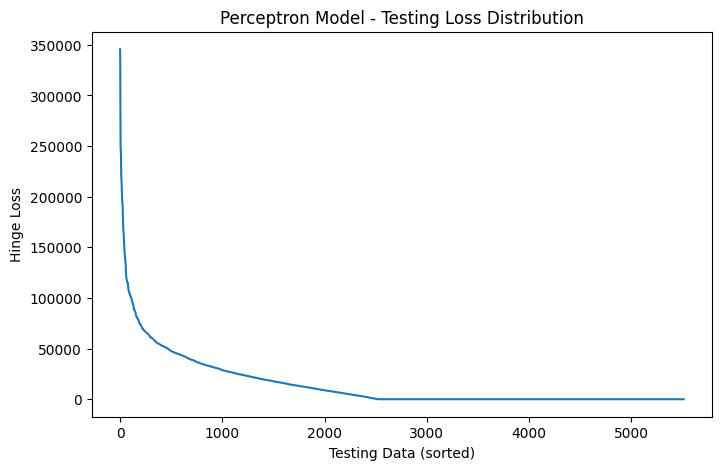

In [76]:
plt.figure(figsize=(8,5))
plt.plot(range(len(hinge_losses)), np.sort(hinge_losses)[::-1])
plt.xlabel('Testing Data (sorted)')
plt.ylabel('Hinge Loss')
plt.title('Perceptron Model - Testing Loss Distribution')
plt.show()

## **Multi-Layer Perceptron

In [7]:
import os
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, classification_report
import matplotlib.pyplot as plt

# Dataset path
DATA_DIR = "/kaggle/input/cell-images-for-detecting-malaria/cell_images/cell_images"

In [8]:
img_size = (128, 128)
X = []
y = []

def load_images(folder, label, limit=None):
    path = os.path.join(DATA_DIR, folder)
    files = os.listdir(path)
    if limit: files = files[:limit]
    for f in files:
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            img = Image.open(os.path.join(path, f)).convert('RGB')
            img = img.resize(img_size)
            X.append(np.array(img).flatten() / 255.0)  # normalize
            y.append(label)

# Load both classes
load_images("Uninfected", 0)
load_images("Parasitized", 1)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

print(f"Total images: {len(X)}")
print(f"Uninfected: {sum(y==0)}, Parasitized: {sum(y==1)}")

Total images: 27558
Uninfected: 13779, Parasitized: 13779


In [9]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train)
y_train = torch.tensor(y_train).unsqueeze(1)  # shape (N,1)
X_test  = torch.tensor(X_test)
y_test  = torch.tensor(y_test).unsqueeze(1)

print(f"Train samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")


Train samples: 22046, Test samples: 5512


In [12]:
class MLP(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)
        
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        return x

model = MLP(input_size=X_train.shape[1])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [14]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train.to(device))
    loss = criterion(outputs, y_train.to(device))
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 1/20, Loss: 0.8496
Epoch 2/20, Loss: 2.9305
Epoch 3/20, Loss: 1.5210
Epoch 4/20, Loss: 0.7285
Epoch 5/20, Loss: 0.9620
Epoch 6/20, Loss: 0.8040
Epoch 7/20, Loss: 0.6810
Epoch 8/20, Loss: 0.7598
Epoch 9/20, Loss: 0.7374
Epoch 10/20, Loss: 0.6877
Epoch 11/20, Loss: 0.6922
Epoch 12/20, Loss: 0.7207
Epoch 13/20, Loss: 0.7120
Epoch 14/20, Loss: 0.6858
Epoch 15/20, Loss: 0.6831
Epoch 16/20, Loss: 0.6941
Epoch 17/20, Loss: 0.6872
Epoch 18/20, Loss: 0.6743
Epoch 19/20, Loss: 0.6805
Epoch 20/20, Loss: 0.6850


In [15]:
model.eval()
with torch.no_grad():
    y_probs = model(X_test.to(device)).cpu().numpy()
    y_pred = (y_probs > 0.5).astype(int)

# Metrics
acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probs)
cm = confusion_matrix(y_test, y_pred)

print(f"Test Accuracy: {acc:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print("Confusion Matrix:")
print(cm)

Test Accuracy: 0.5561
ROC-AUC: 0.6556
Confusion Matrix:
[[2345  411]
 [2036  720]]


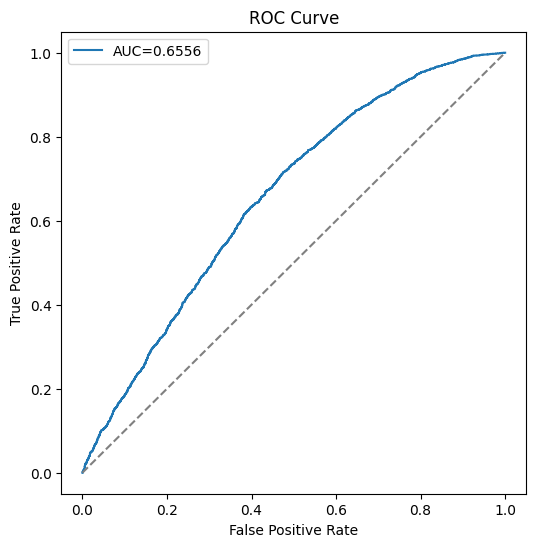

In [16]:
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC={roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## K-Means Clustering Classifier

In [27]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.cluster import KMeans
from collections import Counter
import pandas as pd
import tensorflow as tf

all_files = []
for folder in [uninfected_path, parasitized_path]:
    files = [os.path.join(folder, f) for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg'))]
    all_files.extend(files)

print(f"Total combined images: {len(all_files)}")

# Resize images to 128x128 and normalize
images = []
image_files = []

for file in all_files:
    try:
        img = Image.open(file).convert("RGB")
        img = img.resize((128, 128))
        img_array = np.array(img) / 255.0
        images.append(img_array)
        image_files.append(file)
    except Exception as e:
        print(f"Skipped {file} due to error: {e}")

images = np.array(images, dtype=np.float32)
print(f"Loaded {len(images)} valid images")

Total combined images: 27558
Loaded 27558 valid images


In [28]:
# Resize images to 128x128 and normalize
images = []
image_files = []

for file in all_files:
    try:
        img = Image.open(file).convert("RGB")
        img = img.resize((128, 128))
        img_array = np.array(img) / 255.0
        images.append(img_array)
        image_files.append(file)
    except Exception as e:
        print(f"Skipped {file} due to error: {e}")

images = np.array(images, dtype=np.float32)
print(f"Loaded {len(images)} valid images")

Loaded 27558 valid images


I0000 00:00:1760081321.606378      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13252 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1760081321.607017      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Extracting features...


I0000 00:00:1760081339.088280     161 service.cc:148] XLA service 0x7a430c04f520 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760081339.089142     161 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1760081339.089163     161 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1760081339.590419     161 cuda_dnn.cc:529] Loaded cuDNN version 90300


 15/862 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step

I0000 00:00:1760081342.137477     161 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


862/862 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step
Feature extraction complete.


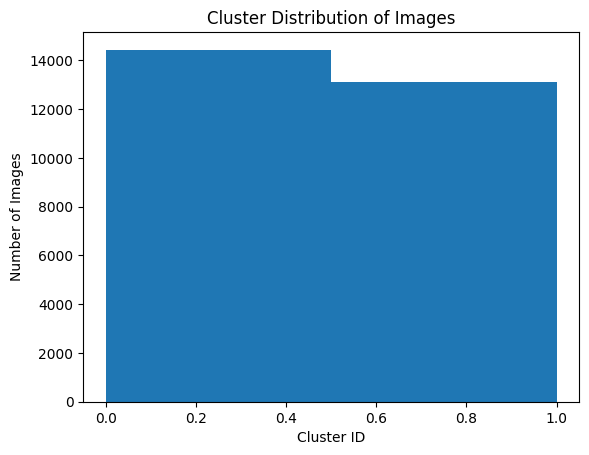

In [29]:
base_model = tf.keras.applications.MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3),
    pooling='avg'  # Global average pooling to get a feature vector
)

print("Extracting features...")
features = base_model.predict(images, batch_size=32, verbose=1)
print("Feature extraction complete.")

num_clusters = 2  # Because we have Uninfected vs Parasitized
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(features)

# Visualize distribution
plt.hist(cluster_labels, bins=num_clusters)
plt.xlabel("Cluster ID")
plt.ylabel("Number of Images")
plt.title("Cluster Distribution of Images")
plt.show()

In [30]:
from collections import Counter

# Count how many images in each cluster
counts = Counter(cluster_labels)
for cluster_id, count in counts.items():
    print(f"Cluster {cluster_id}: {count} images")

Cluster 0: 14432 images
Cluster 1: 13126 images


In [31]:
# Build dataframe
df_clusters = pd.DataFrame({
    "File": image_files,
    "Cluster": cluster_labels
})

# Separate files by cluster
cluster_0_files = df_clusters[df_clusters["Cluster"] == 0]["File"].tolist()
cluster_1_files = df_clusters[df_clusters["Cluster"] == 1]["File"].tolist()

print("Cluster 0 images:", len(cluster_0_files))
print("Cluster 1 images:", len(cluster_1_files))

df_clusters.head()

Cluster 0 images: 14432
Cluster 1 images: 13126


,File,Cluster
0,/kaggle/input/cell-images-for-detecting-malari...,0
1,/kaggle/input/cell-images-for-detecting-malari...,1
2,/kaggle/input/cell-images-for-detecting-malari...,1
3,/kaggle/input/cell-images-for-detecting-malari...,1
4,/kaggle/input/cell-images-for-detecting-malari...,1


In [32]:
# Collect filenames from each original folder
uninfected_files = set(os.listdir(uninfected_path))
parasitized_files = set(os.listdir(parasitized_path))

# Function to count how many images in a cluster belong to a given folder
def count_in_folder(file_list, folder_files):
    return sum(1 for f in file_list if os.path.basename(f) in folder_files)

# Cluster 0 counts
c0_uninfected = count_in_folder(cluster_0_files, uninfected_files)
c0_parasitized = count_in_folder(cluster_0_files, parasitized_files)

# Cluster 1 counts
c1_uninfected = count_in_folder(cluster_1_files, uninfected_files)
c1_parasitized = count_in_folder(cluster_1_files, parasitized_files)

# Print summary
print("Cluster 0:")
print(f"  Uninfected: {c0_uninfected}")
print(f"  Parasitized: {c0_parasitized}")

print("\nCluster 1:")
print(f"  Uninfected: {c1_uninfected}")
print(f"  Parasitized: {c1_parasitized}")

Cluster 0:
  Uninfected: 8427
  Parasitized: 6005

Cluster 1:
  Uninfected: 5352
  Parasitized: 7774


## K-Fold Out-of-Fold (OOF)

In [57]:
# # **Implementing K-Fold Out-of-Fold (OOF) Training to Identify Mislabelled Images**

import warnings
import os

# Hide warnings
warnings.filterwarnings("ignore")

get_ipython().system('pip install torch torchvision timm scikit-learn tqdm')

import os, math
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import StratifiedKFold 
import numpy as np
from tqdm import tqdm
import random
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Set seed value
SEED = 42

#generators
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Ensure deterministic behavior (for CUDA)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Dataset + training parameters
DATA_DIR = "/kaggle/input/cell-images-for-detecting-malaria/cell_images/cell_images"
BATCH_SIZE = 64
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_FOLDS = 5
EPOCHS = 3  # small number for quick tests

# Dataset and transforms
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])
full_dataset = datasets.ImageFolder(DATA_DIR, transform=transform)
labels = np.array([y for _, y in full_dataset])

# producing out-of-fold probabilities for each example
oof_probs = np.zeros((len(full_dataset), 2))  # two classes

fold_accuracies = []

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels)), labels)):
    print(f"Fold {fold+1}/{N_FOLDS}")
    train_ds = Subset(full_dataset, train_idx)
    val_ds = Subset(full_dataset, val_idx)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

    # pretrained model-ResNet18
    model = models.resnet18(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, 2)
    model = model.to(DEVICE)

    opt = torch.optim.Adam(model.parameters(), lr=1e-4)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(EPOCHS):
        model.train()
        for imgs, ys in train_loader:
            imgs, ys = imgs.to(DEVICE), ys.to(DEVICE)
            opt.zero_grad()
            logits = model(imgs)
            loss = loss_fn(logits, ys)
            loss.backward()
            opt.step()
    
    #inference on val (OOF)
    model.eval()
    val_preds, val_true = [], []
    with torch.no_grad():
        idx_list = val_idx.tolist()
        p = []
        for imgs, ys in val_loader:
            imgs, ys = imgs.to(DEVICE), ys.to(DEVICE)
            logits = model(imgs)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = logits.argmax(dim=1).cpu().numpy()
    
            val_preds.extend(preds)
            val_true.extend(ys.cpu().numpy())
            p.append(probs)
    
        p = np.vstack(p)
        oof_probs[idx_list] = p
    
    # Compute fold accuracy
    acc = accuracy_score(val_true, val_preds)
    fold_accuracies.append(acc)
    print(f"Fold {fold+1} Validation Accuracy: {acc:.4f}")

#After all folds
mean_acc = np.mean(fold_accuracies)
print("\nCross-validation Results")
for i, acc in enumerate(fold_accuracies, 1):
    print(f"Fold {i} Accuracy: {acc:.4f}")
print(f"Mean Validation Accuracy: {mean_acc:.4f}")

#OOF Evaluation
oof_preds = oof_probs.argmax(axis=1)
oof_acc = accuracy_score(labels, oof_preds)
oof_f1 = f1_score(labels, oof_preds)
print("\nOverall OOF Performance")
print(f"OOF Accuracy: {oof_acc:.4f}")
print(f"OOF F1 Score: {oof_f1:.4f}")
print(confusion_matrix(labels, oof_preds))
print(classification_report(labels, oof_preds, target_names=full_dataset.classes))

# Flagging suspicious images
# For each example, check model predicted class and prob of assigned class
assigned_label = labels
pred_label = oof_probs.argmax(axis=1)
prob_true_label = oof_probs[np.arange(len(labels)), assigned_label]

# Flags
flag_swap = pred_label != assigned_label  # model predicts other class
flag_low_conf = prob_true_label < 0.25   # threshold: assigned label gets < 25% prob
flag_high_conf_swap = (pred_label != assigned_label) & (oof_probs.max(axis=1) > 0.7)

priority_idx = np.where(flag_high_conf_swap)[0]  # highest priority to review
maybe_idx = np.where(flag_low_conf & ~flag_high_conf_swap)[0]

Fold 1/5
Fold 1 Validation Accuracy: 0.9692
Fold 2/5
Fold 2 Validation Accuracy: 0.9688
Fold 3/5
Fold 3 Validation Accuracy: 0.9713
Fold 4/5
Fold 4 Validation Accuracy: 0.9646
Fold 5/5
Fold 5 Validation Accuracy: 0.9697

Cross-validation Results
Fold 1 Accuracy: 0.9692
Fold 2 Accuracy: 0.9688
Fold 3 Accuracy: 0.9713
Fold 4 Accuracy: 0.9646
Fold 5 Accuracy: 0.9697
Mean Validation Accuracy: 0.9687

Overall OOF Performance
OOF Accuracy: 0.9687
OOF F1 Score: 0.9689
[[13255   524]
 [  338 13441]]
              precision    recall  f1-score   support

 Parasitized       0.98      0.96      0.97     13779
  Uninfected       0.96      0.98      0.97     13779

    accuracy                           0.97     27558
   macro avg       0.97      0.97      0.97     27558
weighted avg       0.97      0.97      0.97     27558



In [58]:
print("Total images:", len(full_dataset))
print("Potential swaps (model predicts opposite):", flag_swap.sum())
print("High-confidence swaps (p>0.7):", flag_high_conf_swap.sum())

Total images: 27558
Potential swaps (model predicts opposite): 862
High-confidence swaps (p>0.7): 591


In [38]:
import pandas as pd
import numpy as np

# Get indices where the predicted label ≠ true label
swap_indices = np.where(pred_label != assigned_label)[0]

print(f"Saving {len(swap_indices)} potential swaps...")

records = []
for idx in swap_indices:
    img_path, true_label = full_dataset.samples[idx]
    pred = pred_label[idx]
    prob_true = prob_true_label[idx]
    prob_pred = oof_probs[idx, pred]
    records.append({
        "image_path": img_path,
        "true_label": full_dataset.classes[true_label],
        "predicted_label": full_dataset.classes[pred],
        "prob_true_label": round(prob_true, 4),
        "prob_predicted_label": round(prob_pred, 4),
    })

# Create DataFrame and save
df = pd.DataFrame(records)
df.to_csv("Potential_Swaps.csv", index=False)
print(" Saved to: Potential_Swaps_.csv")



Saving 862 potential swaps...
 Saved to: Potential_Swaps_.csv


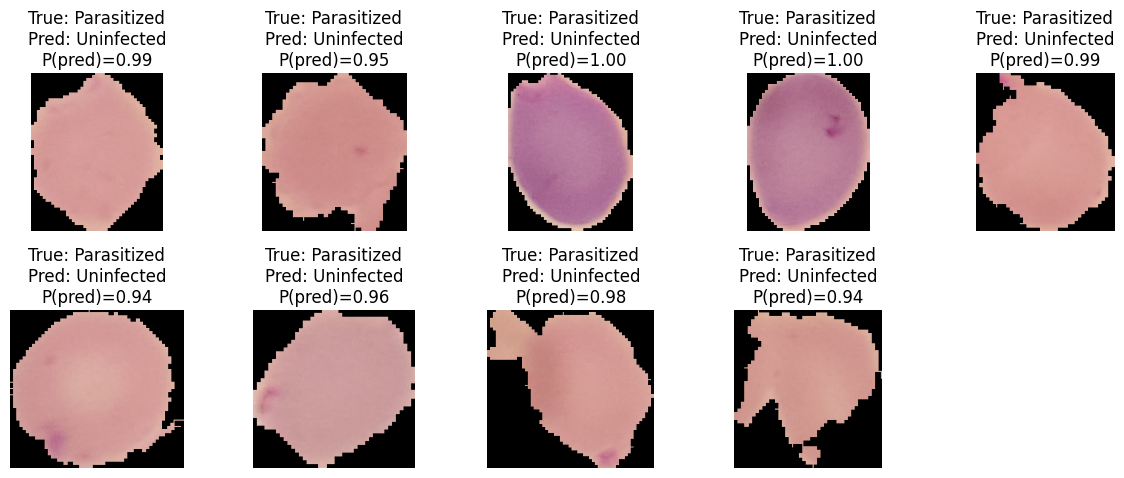

348


In [39]:
# # **Selecting images with p>0.90**

import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# High-confidence swaps: model predicts other class with P > 0.9
high_conf_idx = np.where((pred_label != labels) & (oof_probs.max(axis=1) > 0.90))[0]

# Show first 9 high-confidence swaps
plt.figure(figsize=(12, 12))
for i, idx in enumerate(high_conf_idx[:9]):
    img_path, true_idx = full_dataset.samples[idx]
    pred_idx = pred_label[idx]

    img = Image.open(img_path).convert("RGB")

    plt.subplot(5,5, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"True: {full_dataset.classes[true_idx]}\nPred: {full_dataset.classes[pred_idx]}\nP(pred)={oof_probs[idx, pred_idx]:.2f}")
plt.tight_layout()
plt.show()
print(len(high_conf_idx))

In [40]:
import pandas as pd
import numpy as np

# Probabilities of predicted class
prob_pred = oof_probs.max(axis=1)

# High-confidence swaps: model predicts other class with P > 0.9
high_conf_idx = np.where((pred_label != labels) & (prob_pred > 0.9))[0]

print("Number of high-confidence swaps:", len(high_conf_idx))

# Collect data
filenames = [full_dataset.samples[i][0] for i in high_conf_idx]
true_labels = [full_dataset.classes[labels[i]] for i in high_conf_idx]
pred_labels = [full_dataset.classes[pred_label[i]] for i in high_conf_idx]
prob_true = [prob_true_label[i] for i in high_conf_idx]
prob_pred_vals = [prob_pred[i] for i in high_conf_idx]

# Create DataFrame
df_high_conf = pd.DataFrame({
    "filename": filenames,
    "true_label": true_labels,
    "pred_label": pred_labels,
    "prob_true_label": prob_true,
    "prob_pred_label": prob_pred_vals
})

# Save to CSV
df_high_conf.to_csv("p>0.9_swaps.csv", index=False)
print("p>0.9_swaps.csv'")


# # **CSV columns**
# filename :path to image
# 
# true_label :current folder
# 
# pred_label : predicted label by the model
# 
# prob_true_label : probability model gave to current label
# 
# prob_pred_label : probability model gave to predicted label

Number of high-confidence swaps: 348
p>0.9_swaps.csv'


# Pre cleaning for before Modelling

In [7]:
import pandas as pd
import os
from pathlib import Path
from torchvision import datasets, transforms

# Paths
DATA_DIR = Path("/kaggle/input/cell-images-for-detecting-malaria/cell_images/cell_images")
CSV_PATH = Path("/kaggle/input/manually-checked-2/Manually checked (2).csv") 

# Load the CSV of images you want to drop
df = pd.read_csv(CSV_PATH)

#  Normalize filenames to match ImageFolder convention
df['filename'] = (
    df['filename']
    .str.replace(r'.*/', '', regex=True)  # remove folder structure if present
    .str.strip()
    .str.lower()
)

bad_filenames = set(df['filename'])

# Load your full dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
full_dataset = datasets.ImageFolder(DATA_DIR, transform=transform)

# Build a filtered list of indices to keep
keep_indices = []
for i, (path, _) in enumerate(full_dataset.samples):
    filename = os.path.basename(path).lower()
    if filename not in bad_filenames:
        keep_indices.append(i)

print(f"Keeping {len(keep_indices)} images (removed {len(full_dataset) - len(keep_indices)} misclassified ones).")

# Create a filtered dataset
from torch.utils.data import Subset
filtered_dataset = Subset(full_dataset, keep_indices)

Keeping 27188 images (removed 370 misclassified ones).


# CNN Model Training

In [5]:
import os
import random
from pathlib import Path
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import torch.nn as nn
import torch.optim as optim

In [44]:
DATA_DIR = "/kaggle/input/cell-images-for-detecting-malaria/cell_images/cell_images"

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

# Load dataset
full_dataset = datasets.ImageFolder(DATA_DIR, transform=transform)

# Suppose you already have keep_indices (from your filtering step)
filtered_dataset = torch.utils.data.Subset(full_dataset, keep_indices)

print(f"Keeping {len(filtered_dataset)} images after filtering.")

Keeping 27188 images after filtering.


In [45]:
train_ratio, val_ratio, test_ratio = 0.7, 0.15, 0.15

train_size = int(train_ratio * len(filtered_dataset))
val_size   = int(val_ratio * len(filtered_dataset))
test_size  = len(filtered_dataset) - train_size - val_size

train_set, val_set, test_set = random_split(
    filtered_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Train: {len(train_set)}, Validation: {len(val_set)}, Test: {len(test_set)}")

Train: 19031, Validation: 4078, Test: 4079


In [46]:
BATCH_SIZE = 32

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

In [47]:
class CNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(32), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(64), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(128), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [49]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNClassifier().to(device)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [50]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

EPOCHS = 30

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = (outputs > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = (outputs > 0.5).float()
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}]  "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}  "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch [1/30]  Train Loss: 0.4075 | Train Acc: 0.8156  Val Loss: 0.2646 | Val Acc: 0.9083
Epoch [2/30]  Train Loss: 0.1786 | Train Acc: 0.9347  Val Loss: 0.1237 | Val Acc: 0.9514
Epoch [3/30]  Train Loss: 0.1329 | Train Acc: 0.9539  Val Loss: 0.1173 | Val Acc: 0.9559
Epoch [4/30]  Train Loss: 0.1072 | Train Acc: 0.9621  Val Loss: 0.1059 | Val Acc: 0.9644
Epoch [5/30]  Train Loss: 0.0895 | Train Acc: 0.9685  Val Loss: 0.0999 | Val Acc: 0.9625
Epoch [6/30]  Train Loss: 0.0760 | Train Acc: 0.9734  Val Loss: 0.1111 | Val Acc: 0.9640
Epoch [7/30]  Train Loss: 0.0679 | Train Acc: 0.9757  Val Loss: 0.1221 | Val Acc: 0.9640
Epoch [8/30]  Train Loss: 0.0534 | Train Acc: 0.9813  Val Loss: 0.1109 | Val Acc: 0.9681
Epoch [9/30]  Train Loss: 0.0472 | Train Acc: 0.9834  Val Loss: 0.1064 | Val Acc: 0.9706
Epoch [10/30]  Train Loss: 0.0343 | Train Acc: 0.9883  Val Loss: 0.1324 | Val Acc: 0.9640
Epoch [11/30]  Train Loss: 0.0302 | Train Acc: 0.9896  Val Loss: 0.1125 | Val Acc: 0.9686
Epoch [12/30]  Trai

In [51]:
model.eval()
correct, total, test_loss = 0, 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        preds = (outputs > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)


test_loss = test_loss / len(test_loader)
print(f"Final Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {correct / total:.4f}")

Final Test Loss: 0.1883
Test Accuracy: 0.9694


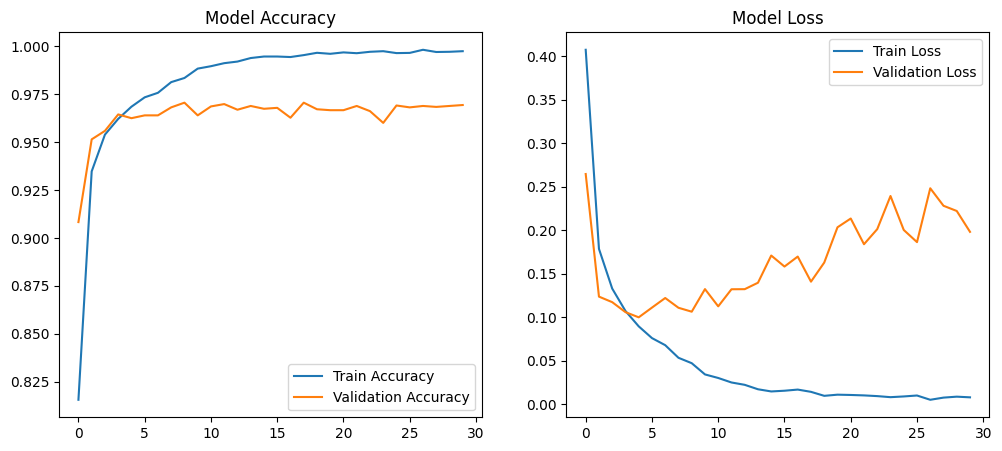

In [52]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1,2,2)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

In [53]:
from torchsummary import summary

summary(model, (3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
              ReLU-2         [-1, 32, 128, 128]               0
       BatchNorm2d-3         [-1, 32, 128, 128]              64
         MaxPool2d-4           [-1, 32, 64, 64]               0
            Conv2d-5           [-1, 64, 64, 64]          18,496
              ReLU-6           [-1, 64, 64, 64]               0
       BatchNorm2d-7           [-1, 64, 64, 64]             128
         MaxPool2d-8           [-1, 64, 32, 32]               0
            Conv2d-9          [-1, 128, 32, 32]          73,856
             ReLU-10          [-1, 128, 32, 32]               0
      BatchNorm2d-11          [-1, 128, 32, 32]             256
        MaxPool2d-12          [-1, 128, 16, 16]               0
          Flatten-13                [-1, 32768]               0
           Linear-14                  [

Final Test Loss: 0.5233
Test Accuracy: 0.9174
ROC-AUC Score: 0.9935


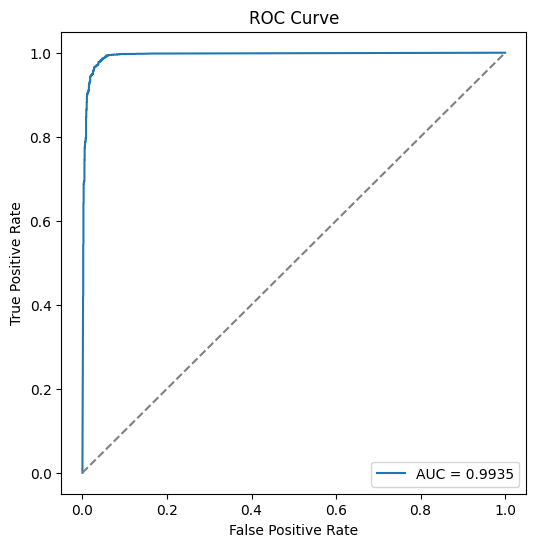

In [54]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

model.eval()
correct, total, test_loss = 0, 0, 0
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs)  # probabilities
        loss = criterion(probs, labels)
        test_loss += loss.item()
        
        preds = (probs > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        # Store for AUC-ROC
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

test_loss /= len(test_loader)
test_acc = correct / total

print(f"Final Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Compute ROC-AUC
roc_auc = roc_auc_score(all_labels, all_probs)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()



Detailed Performance Metrics:
Precision   : 0.8571
Sensitivity : 0.9980
Specificity : 0.8397
F1-score    : 0.9222


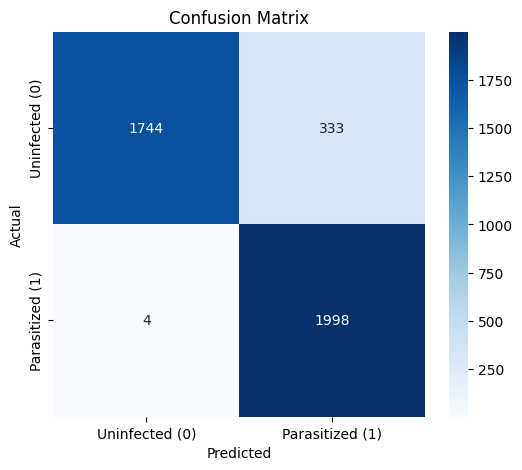

In [55]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns

# Convert to numpy arrays
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
all_preds = (all_probs > 0.5).astype(int)

# --- Compute Metrics ---
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)  # sensitivity
f1 = f1_score(all_labels, all_preds)

# Confusion matrix to get TN, FP, FN, TP for specificity
cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

# --- Print Metrics ---
print("\nDetailed Performance Metrics:")
print(f"Precision   : {precision:.4f}")
print(f"Sensitivity : {recall:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"F1-score    : {f1:.4f}")

# --- Confusion Matrix Visualization ---
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Uninfected (0)', 'Parasitized (1)'],
            yticklabels=['Uninfected (0)', 'Parasitized (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# CNN with upgrades

In [13]:
import os
import random
from pathlib import Path
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import torch.nn as nn
import torch.optim as optim

In [14]:
DATA_DIR = "/kaggle/input/cell-images-for-detecting-malaria/cell_images/cell_images"

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

# Load dataset
full_dataset = datasets.ImageFolder(DATA_DIR, transform=transform)

# Suppose you already have keep_indices (from your filtering step)
filtered_dataset = torch.utils.data.Subset(full_dataset, keep_indices)

print(f"Keeping {len(filtered_dataset)} images after filtering.")

Keeping 27188 images after filtering.


In [15]:
train_ratio, val_ratio, test_ratio = 0.7, 0.15, 0.15

train_size = int(train_ratio * len(filtered_dataset))
val_size   = int(val_ratio * len(filtered_dataset))
test_size  = len(filtered_dataset) - train_size - val_size

train_set, val_set, test_set = random_split(
    filtered_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Train: {len(train_set)}, Validation: {len(val_set)}, Test: {len(test_set)}")

Train: 19031, Validation: 4078, Test: 4079


In [16]:
BATCH_SIZE = 32

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

In [17]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomResizedCrop(128, scale=(0.8,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(), #Improve
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomAffine(0, translate=(0.1,0.1)),  #Improve
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [18]:
class AdvancedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(32), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(64), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(128), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(256), nn.MaxPool2d(2),
            nn.Conv2d(256, 512, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(512), nn.MaxPool2d(2),  #added layer
        )
        # self.classifier = nn.Sequential(
        #     nn.Flatten(),
        #     nn.Linear(256 * 8 * 8, 256),
        #     nn.ReLU(),
        #     nn.Dropout(0.5),
        #     nn.Linear(256, 1),
        #     #nn.Sigmoid()   # Improve
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
adv_model = AdvancedCNN().to(device)

#criterion = nn.BCELoss()
criterion = nn.BCEWithLogitsLoss()   #Improve
optimizer = optim.Adam(adv_model.parameters(), lr=3e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,      # reduce LR by 0.5
    patience=4,      # wait 4 epochs before reducing
    min_lr = 1e-6,
    verbose=True
)

In [21]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

EPOCHS = 50
patience = 25
best_val_loss = float("inf")
early_stop_counter = 0

for epoch in range(EPOCHS):
    adv_model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
        
        optimizer.zero_grad()
        outputs = adv_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = (outputs > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    # Validation
    adv_model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
            outputs = adv_model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = (outputs > 0.5).float()
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    scheduler.step(val_loss)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}]  "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}  "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch [1/50]  Train Loss: 0.1818 | Train Acc: 0.9307  Val Loss: 0.1054 | Val Acc: 0.9662
Epoch [2/50]  Train Loss: 0.1088 | Train Acc: 0.9640  Val Loss: 0.0922 | Val Acc: 0.9669
Epoch [3/50]  Train Loss: 0.0927 | Train Acc: 0.9693  Val Loss: 0.0982 | Val Acc: 0.9676
Epoch [4/50]  Train Loss: 0.0824 | Train Acc: 0.9697  Val Loss: 0.0903 | Val Acc: 0.9625
Epoch [5/50]  Train Loss: 0.0760 | Train Acc: 0.9734  Val Loss: 0.0916 | Val Acc: 0.9679
Epoch [6/50]  Train Loss: 0.0702 | Train Acc: 0.9745  Val Loss: 0.0867 | Val Acc: 0.9686
Epoch [7/50]  Train Loss: 0.0619 | Train Acc: 0.9789  Val Loss: 0.0877 | Val Acc: 0.9708
Epoch [8/50]  Train Loss: 0.0555 | Train Acc: 0.9795  Val Loss: 0.0922 | Val Acc: 0.9689
Epoch [9/50]  Train Loss: 0.0485 | Train Acc: 0.9817  Val Loss: 0.0831 | Val Acc: 0.9689
Epoch [10/50]  Train Loss: 0.0439 | Train Acc: 0.9833  Val Loss: 0.0916 | Val Acc: 0.9720
Epoch [11/50]  Train Loss: 0.0344 | Train Acc: 0.9869  Val Loss: 0.1107 | Val Acc: 0.9730
Epoch [12/50]  Trai

In [22]:
adv_model.eval()
correct, total, test_loss = 0, 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
        outputs = adv_model(images)
        outputs = torch.sigmoid(outputs) #improve
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        preds = (outputs > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)


test_loss = test_loss / len(test_loader)
print(f"Final Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {correct / total:.4f}")

Final Test Loss: 0.5166
Test Accuracy: 0.9816


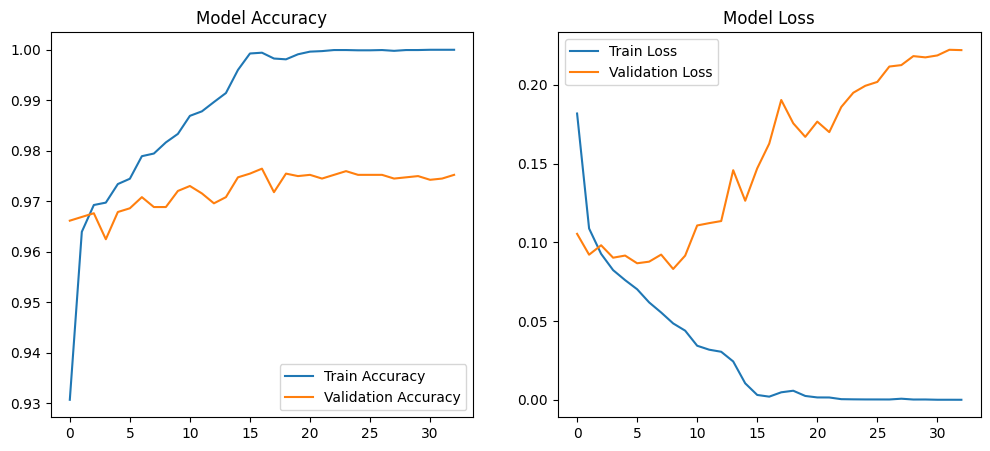

In [23]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1,2,2)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

In [24]:
from torchsummary import summary

summary(adv_model, (3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
              ReLU-2         [-1, 32, 128, 128]               0
       BatchNorm2d-3         [-1, 32, 128, 128]              64
         MaxPool2d-4           [-1, 32, 64, 64]               0
            Conv2d-5           [-1, 64, 64, 64]          18,496
              ReLU-6           [-1, 64, 64, 64]               0
       BatchNorm2d-7           [-1, 64, 64, 64]             128
         MaxPool2d-8           [-1, 64, 32, 32]               0
            Conv2d-9          [-1, 128, 32, 32]          73,856
             ReLU-10          [-1, 128, 32, 32]               0
      BatchNorm2d-11          [-1, 128, 32, 32]             256
        MaxPool2d-12          [-1, 128, 16, 16]               0
           Conv2d-13          [-1, 256, 16, 16]         295,168
             ReLU-14          [-1, 256,

Final Test Loss: 0.5166
Test Accuracy: 0.9816
ROC-AUC Score: 0.9971


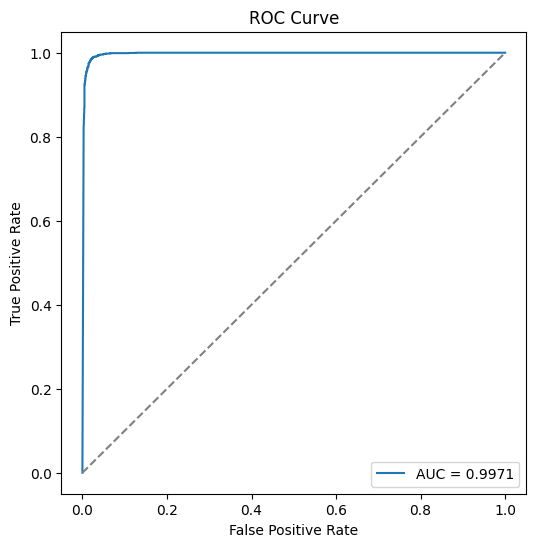

In [25]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

adv_model.eval()
correct, total, test_loss = 0, 0, 0
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
        outputs = adv_model(images)
        probs = torch.sigmoid(outputs)  # probabilities
        loss = criterion(probs, labels)
        test_loss += loss.item()
        
        preds = (probs > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        # Store for AUC-ROC
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

test_loss /= len(test_loader)
test_acc = correct / total

print(f"Final Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Compute ROC-AUC
roc_auc = roc_auc_score(all_labels, all_probs)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()



Detailed Performance Metrics:
Precision   : 0.9767
Sensitivity : 0.9860
Specificity : 0.9774
F1-score    : 0.9814


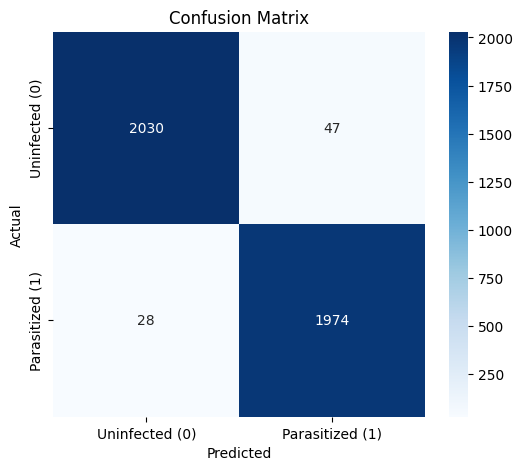

In [42]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns

# Convert to numpy arrays
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
all_preds = (all_probs > 0.5).astype(int)

# --- Compute Metrics ---
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)  # sensitivity
f1 = f1_score(all_labels, all_preds)

# Confusion matrix to get TN, FP, FN, TP for specificity
cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

# --- Print Metrics ---
print("\nDetailed Performance Metrics:")
print(f"Precision   : {precision:.4f}")
print(f"Sensitivity : {recall:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"F1-score    : {f1:.4f}")

# --- Confusion Matrix Visualization ---
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Uninfected (0)', 'Parasitized (1)'],
            yticklabels=['Uninfected (0)', 'Parasitized (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()